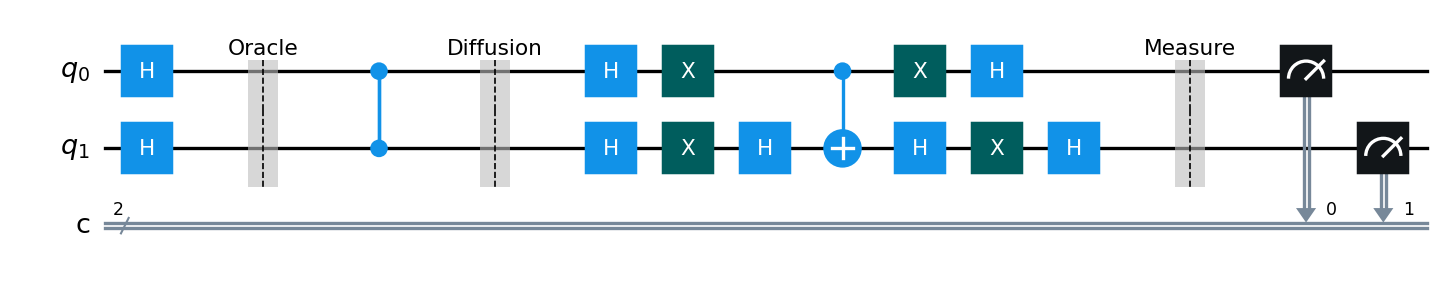

Measurement Counts:
{'11': 1024}


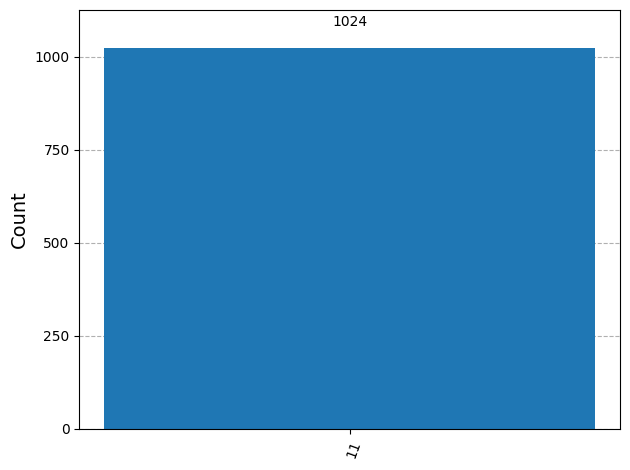

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Create Grover Circuit
# Target state = |11>

qc = QuantumCircuit(2, 2)

# Step 1: Superposition
qc.h(0)
qc.h(1)

qc.barrier(label="Oracle")

# Step 2: Oracle
qc.cz(0, 1)

qc.barrier(label="Diffusion")

# Step 3: Diffusion Operator
qc.h([0, 1])
qc.x([0, 1])

qc.h(1)
qc.cx(0, 1)
qc.h(1)

qc.x([0, 1])
qc.h([0, 1])

qc.barrier(label="Measure")

# Step 4: Measurement
qc.measure([0, 1], [0, 1])

# Draw Circuit (High Quality)

fig = qc.draw(
    output="mpl",
    style="textbook",
    fold=-1,
    scale=1.2
)

display(fig)

# Save image for GitHub
fig.savefig(
    "grover_circuit.png",
    dpi=300,
    bbox_inches="tight"
)

# Simulation

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

# -----------------------------
# Histogram
# -----------------------------

hist = plot_histogram(counts)

display(hist)

plt.show()